# Phase 4: Model Interpretability with SHAP
## Understanding the Physical Drivers of Fuel Efficiency

**Objective:** Using **SHAP**, we will quantify the impact of each engineering feature (`horsepower`, `curb-weight`, `engine-size`, `width`, `length`, 
            `power_to_weight_ratio`, `vehicle_volume`, `cylinders_int`) on the model's output.

In [25]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

# 1. Load trained artifacts from Phase 3
rf_model = joblib.load('../models/Random_Forest.joblib')
lr_model = joblib.load('../models/Linear_Regression.joblib')
scaler = joblib.load('../models/feature_scaler.joblib')

# 2. Load engineered data
df = pd.read_csv("../data/engineered_automobile.csv")
features = ['horsepower', 'curb-weight', 'engine-size', 'width', 'length', 
            'power_to_weight_ratio', 'vehicle_volume', 'cylinders_int']

# 3. Transform data: SHAP requires features on the same scale used during training
X_scaled = pd.DataFrame(scaler.transform(df[features]), columns=features)

print(f"Artifacts loaded. Ready to analyze {X_scaled.shape[0]} vehicle instances.")

Artifacts loaded. Ready to analyze 203 vehicle instances.


### 1. Linear Regression Interpretability
Linear models are inherently interpretable through coefficients. However, **SHAP Linear Explainer** provides a more consistent view of feature contribution across the entire dataset. 

In this stage, we expect to see global, proportional trends.

Linear Regression SHAP Analysis:


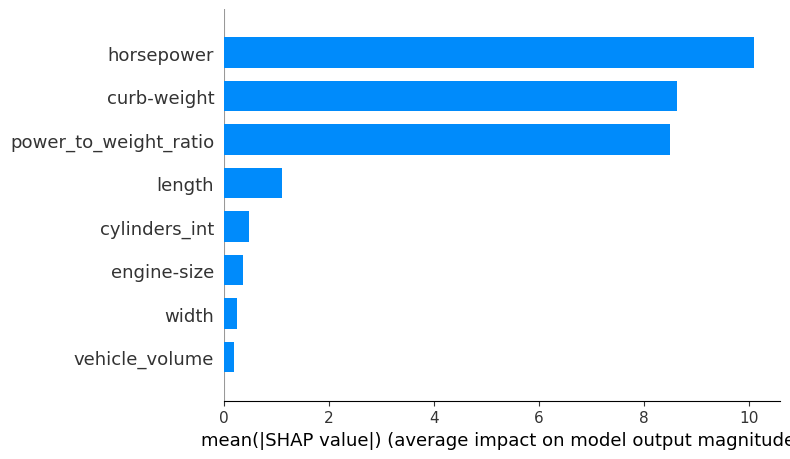

In [26]:

# 1. Create Linear Explainer
lr_explainer = shap.LinearExplainer(lr_model, X_scaled)
lr_shap_values = lr_explainer.shap_values(X_scaled)

print("Linear Regression SHAP Analysis:")
shap.summary_plot(lr_shap_values, X_scaled, plot_type="bar")

### 2. Random Forest Interpretability (TreeExplainer)
Random Forest captures non-linear interactions (e.g., how horsepower impacts MPG differently in heavy vs. light cars). 

We use the **Beeswarm Plot** to visualize:
* **Feature Importance:** Ranked from top to bottom.
* **Impact Direction:** How high/low values (color) push the prediction (left/right).

Random Forest SHAP Analysis:


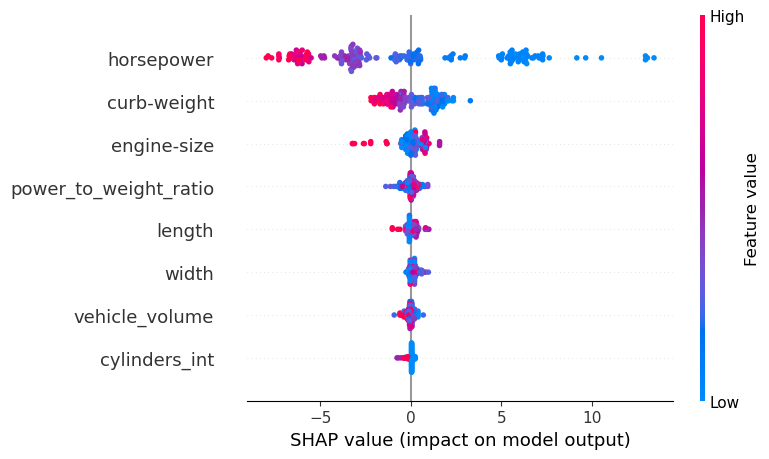

In [27]:
# 2. Create Tree Explainer
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_scaled)

print("Random Forest SHAP Analysis:")
shap.summary_plot(rf_shap_values, X_scaled) # Beeswarm plot

### Engineering Audit: Model Comparison

By comparing both models, we can extract the following business insights:

| Comparison Metric | Linear Regression | Random Forest |
| :--- | :--- | :--- |
| **Top Driver** | Consistent Global Trend | Captures Non-linearities |
| **Physics Check** | High weight reduces MPG linearly. | High weight reduces MPG, but impact varies with engine size. |
| **Recommendation** | Good for quick baseline estimates. | Better for R&D optimization of specific components. |

**Final Conclusion:** The Random Forest model provides a more nuanced understanding of "thermal efficiency," showing that `curb-weight` and `horsepower` are not just independent variables but interacting forces.